<a href="https://colab.research.google.com/github/RudolfVonStroheim/PopulationClassifier/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas-plink
from pandas_plink import read_plink

ERROR: Operation cancelled by user


KeyboardInterrupt: 

In [1]:
!pip install skl2onnx onnxruntime onnxmltools onnxconverter-common
!curl -O http://www.russiangenome.ru/biengi.zip
!unzip biengi.zip -d biengi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 45.2 MB/s eta 0:00:00
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 33.0M  100 33.0M    0     0  2503k      0  0:00:13  0:00:13 --:--:-- 5958k
Archive:  biengi.zip
  inflating: biengi/biengi.bed       
  inflating: biengi/biengi.bim       
  inflating: biengi/biengi.fam       
  inflating: biengi/biengi.pedind    


In [2]:
!wget https://s3.amazonaws.com/plink2-assets/plink2_linux_x86_64_latest.zip -O plink.zip # Скачиваем plink(стандарт в биоинформатике)
!unzip -q -n plink.zip plink2

--2026-06-08 11:36:29--  https://s3.amazonaws.com/plink2-assets/plink2_linux_x86_64_latest.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.223.143, 16.15.244.20, 54.231.167.0, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.223.143|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7618716 (7.3M) [application/zip]
Saving to: ‘plink.zip’

plink.zip           100%[===================>]   7.27M  --.-KB/s    in 0.07s   

2026-06-08 11:36:29 (101 MB/s) - ‘plink.zip’ saved [7618716/7618716]



Данные хранятся в формате SNP(Single Nucleotide Polymorphism): в первом столбце хранится id семьи, во втором - id человека, далее хранятся вариации некоторых генов, встречающихся у этого человека(известны все мутации гена, мутация у конкретного человека описывается номером, номера с вариантами нуклеотидов сопостваляются в отдельном файле(biengi.bim)

In [3]:
!mkdir pruned
!./plink2 --bfile biengi/biengi --indep-pairwise 50 5 0.2 --out biengi/biengi_pruned # Прунинг датасета(мажно сделать средствами python, но так занимает меньше времени)
!./plink2 --bfile biengi/biengi --extract biengi/biengi_pruned.prune.in --make-bed --out pruned/data_pruned

PLINK v2.0.0-a.7.0LM 64-bit Intel (25 Apr 2026)     cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to biengi/biengi_pruned.log.
Options in effect:
  --bfile biengi/biengi
  --indep-pairwise 50 5 0.2
  --out biengi/biengi_pruned

Start time: Mon Jun  8 11:36:35 2026
12975 MiB RAM detected, ~11544 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
894 samples (320 females, 574 males; 894 founders) loaded from
biengi/biengi.fam.
242180 variants loaded from biengi/biengi.bim.
Note: No phenotype data present.
Calculating allele frequencies... 0%27%54%81%done.
--indep-pairwise (2 compute threads): 0%50%162922/242180 variants removed.
Variant lists written to biengi/biengi_pruned.prune.in and
biengi/biengi_pruned.prune.out .
End time: Mon Jun  8 11:36:36 2026
PLINK v2.0.0-a.7.0LM 64-bit Intel (25 Apr 2026)     cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher C

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from skl2onnx import to_onnx
from sklearn.linear_model import LogisticRegression
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import seaborn as sns

In [5]:
# До прунинга
bim, fam, G = read_plink("biengi/biengi")
gn = pd.DataFrame(G.compute().T)
gn

NameError: name 'read_plink' is not defined

In [ ]:
#После прунинга
bim, fam, G = read_plink("pruned/data_pruned")
gn_p = G.compute().T
imp = SimpleImputer(strategy="mean")
gn_p = pd.DataFrame(imp.fit_transform(gn_p))
gn_p.head()

Mapping files: 100%|██████████| 3/3 [00:00<00:00, 21.13it/s]


,0,1,2,3,4,5,6,7,8,9,...,79248,79249,79250,79251,79252,79253,79254,79255,79256,79257
0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0
1,1.0,2.0,1.0,2.0,0.0,1.0,2.0,1.0,2.0,2.0,...,2.0,1.0,1.0,0.0,2.0,2.0,1.0,2.0,2.0,2.0
2,2.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,...,2.0,1.0,0.0,1.0,2.0,1.0,2.0,0.0,2.0,2.0
3,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,1.0,0.0,2.0,2.0,2.0,1.0,0.0,1.0
4,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,...,1.0,2.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0


В результате LD-прунинга количество признаков удалось существенно сократить.
Необходимость данного метода обуславливается спецификой данных: в геноме большое количество блоков очень часто наследуются вместе и при обработке необходимо учитывать весь блок целиком, а не его фрагменты. В итоге число признаков сократилось чуть более, чем в три раза.

Принцип работы алгоритма: датасет сканируется скользящим окном с шириной 500 SNP и шагом 50, для каждой пары SNP считается ковариация. Если квадрат ковариации оказывается больше порога(0.2), один из столбцов удаляется.

In [6]:
!./plink2 --pca 40 --autosome --bfile pruned/data_pruned --out pruned/end_data # Применяем анализ главных компонент

PLINK v2.0.0-a.7.0LM 64-bit Intel (25 Apr 2026)     cog-genomics.org/plink/2.0/
(C) 2005-2026 Shaun Purcell, Christopher Chang    GNU General Public License v3
Logging to pruned/end_data.log.
Options in effect:
  --autosome
  --bfile pruned/data_pruned
  --out pruned/end_data
  --pca 40

Start time: Mon Jun  8 11:36:52 2026
12975 MiB RAM detected, ~11376 available; reserving 6487 MiB for main
workspace.
Using up to 2 compute threads.
894 samples (320 females, 574 males; 894 founders) loaded from
pruned/data_pruned.fam.
79258 variants loaded from pruned/data_pruned.bim (--autosome had no effect).
Note: No phenotype data present.
Calculating allele frequencies... 0%82%done.
Constructing GRM: 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%

In [7]:
vecs = pd.read_csv("pruned/end_data.eigenvec", sep="\t") # Сам набор данных после обработки, необходимое количество главных компонент определится в процессе обучения
vecs.head()

,#FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
0,4461875510_R01C01,4461875510_R01C01,0.023074,0.045581,0.022737,0.010032,-0.007578,0.006535,-0.013364,-0.006449,...,-0.065206,-0.012243,-0.023364,-0.013430,0.037969,0.029122,-0.001439,0.039093,-0.009203,-0.027807
1,4461875510_R01C02,4461875510_R01C02,0.029373,0.032638,0.032961,0.009149,-0.009421,0.015256,-0.004736,-0.005012,...,-0.048925,-0.025044,0.010642,0.031907,0.031323,-0.039249,-0.005607,-0.047750,-0.015266,0.068239
2,4461875510_R02C01,4461875510_R02C01,0.025983,0.044283,0.023562,0.005499,-0.006325,0.020146,-0.013274,-0.011976,...,0.047653,0.008172,-0.038600,0.065165,0.024118,-0.002381,-0.013326,-0.076181,0.053702,-0.015333
3,4461875513_R02C02,4461875513_R02C02,0.022607,0.046587,0.025225,0.014595,-0.009510,0.007256,-0.023022,-0.030881,...,0.027437,0.011815,-0.023411,-0.003881,0.000985,0.028078,-0.003945,0.030586,-0.026530,-0.019413
4,4461875513_R01C02,4461875513_R01C02,0.024328,0.042327,0.017202,0.009732,-0.007187,0.014206,-0.007818,-0.012584,...,-0.054030,-0.021846,0.010952,-0.061781,-0.016466,-0.052021,0.026325,-0.016999,-0.063154,0.005785


In [8]:
tags = pd.read_csv("biengi/biengi.pedind", sep="\t", header=None, usecols=[0, 1, 5], names=["FID", "IID", "Population"]) # Метки(поля - ID семьи, идентификационный ключ, сама раса)
tags.head()

,FID,IID,Population
0,4461875510_R01C01,4461875510_R01C01,Karel
1,4461875510_R01C02,4461875510_R01C02,Karel
2,4461875510_R02C01,4461875510_R02C01,Karel
3,4461875513_R02C02,4461875513_R02C02,Karel
4,4461875513_R01C02,4461875513_R01C02,Karel


In [9]:
tags['Population'].value_counts()

,count
Population,
Kazakh,45
Tuva,44
Buryat,44
Yakut,41
Russian_STV,39
Uzbek,39
Russian_NSK,38
Megrel,36
Kabardin,35


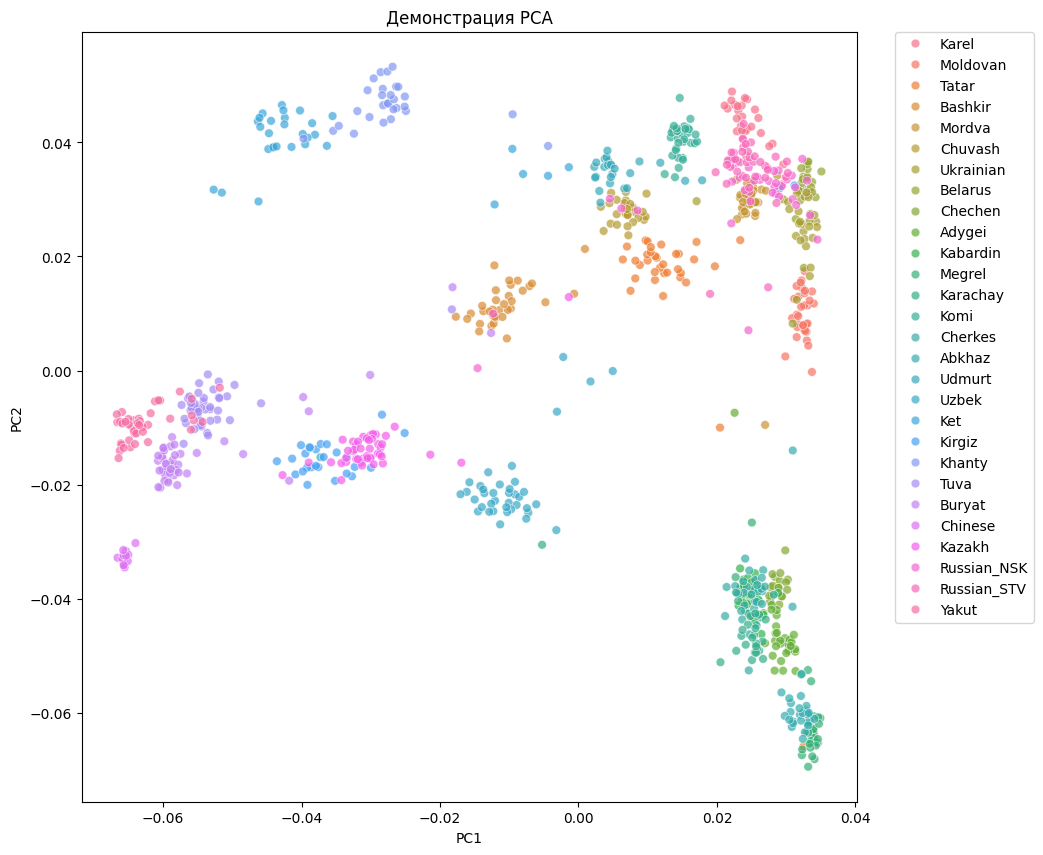

In [ ]:
graph = pd.DataFrame({"PC1": vecs["PC1"], "PC2": vecs["PC2"], "PC3": vecs["PC3"], "Population": tags["Population"]})
plt.figure(figsize=(10, 10))
sns.scatterplot(data=graph, x="PC1", y="PC2", hue="Population", s=40, alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)
plt.title("Демонстрация PCA")
plt.show()

Как видно, уже с помощью первых двух главных компонент можно получить большую часть информации о датасете, что позволяет существенно упростить модели и ускорить обучение. Однако, в результате применения данного метода теряются исходные признаки, что делает анализ представленных данных существенно труднее.

In [16]:
"""Основной цикл обучения, объект модели формирует фабрика"""
def train_and_predict(model_class, x_tr, y_tr, pc_max_count, epochs_count):
  scores = []
  pcas = list(range(2, pc_max_count + 1))
  for i in pcas:
    x_tr_c = x_tr.iloc[:, :i]
    model = model_class(epochs_count)
    score = cross_val_score(model, x_tr_c, y_tr, cv=5).mean()
    scores.append(score)
  plt.figure(figsize=(20,10))
  plt.plot(pcas, scores)
  plt.title("Model scores on different PC counts")
  plt.xlabel("PC count")
  plt.ylabel("Accuracy score")
  plt.xticks(pcas)
  plt.show()
  return model

def export(model, pca_count, all_data, name):
  X = all_data.iloc[:, :pca_count].astype(np.float32)
  calibr_data = X.sample(min(300, len(X)), random_state=42).values
  onx = to_onnx(model, calibr_data[0:1])
  with open(f"model_{name}.onnx", "wb") as f:
    f.write(onx.SerializeToString())
populations = list(np.unique(tags['Population'])) # Превращаем текстовые метки в числа
y = [populations.index(i) for i in tags['Population']]
all_data = vecs.iloc[:, 2:]
all_data['Population'] = y
x_tr, x_test, y_tr, y_test = train_test_split(all_data.iloc[:, :40], all_data['Population'], test_size=0.2, random_state=42)


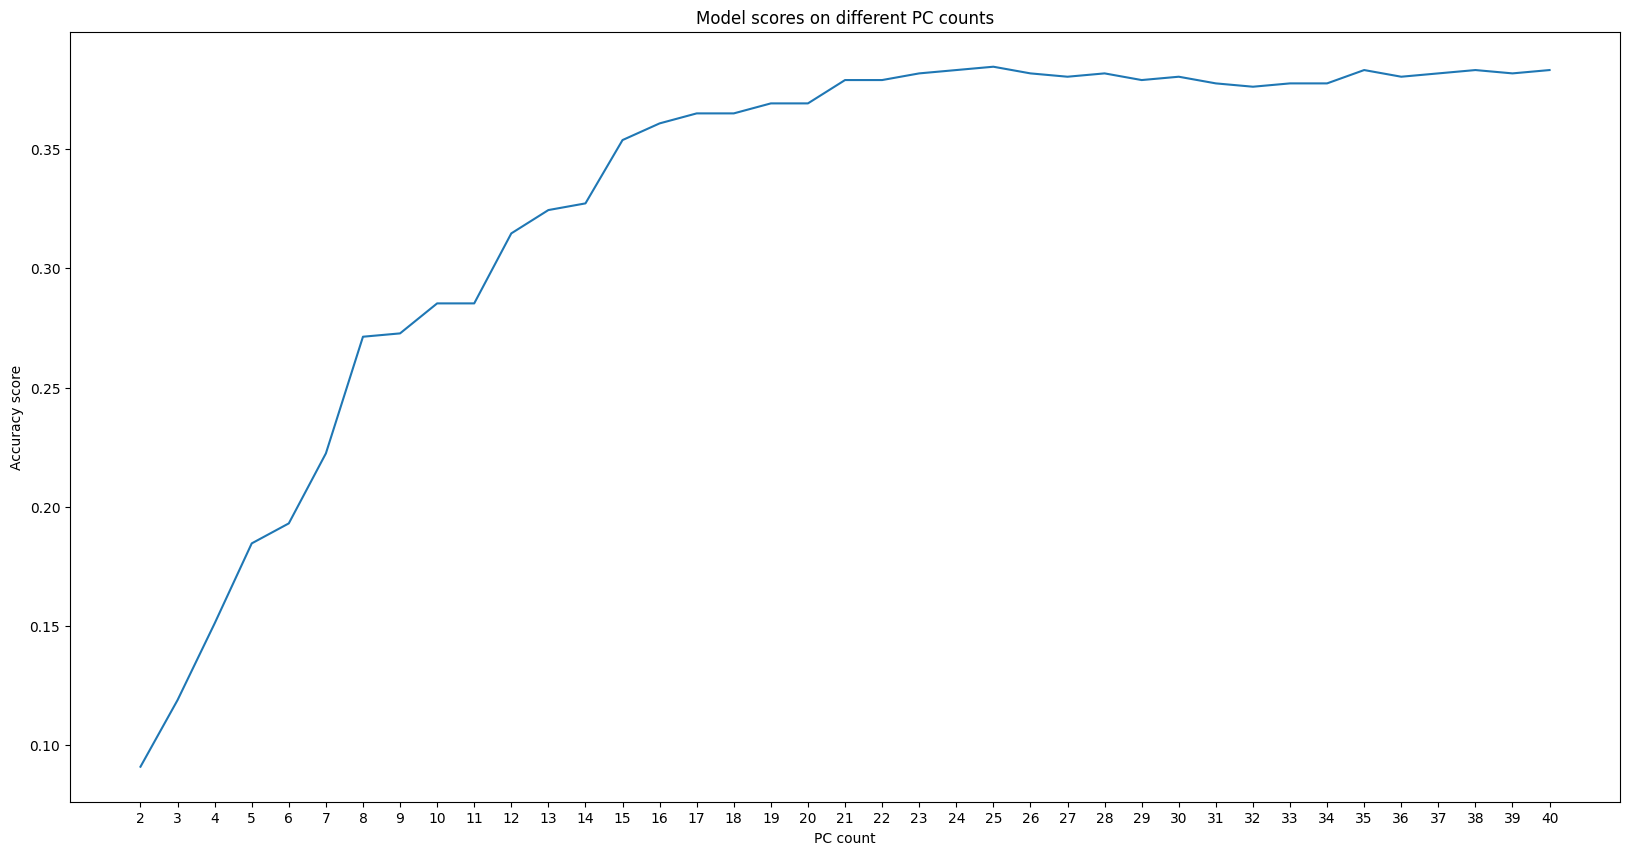

In [17]:
def logistic(epochs):
  return LogisticRegression(solver="lbfgs", max_iter=epochs)
model = train_and_predict(logistic, x_tr, y_tr, 40, 50)

In [27]:
nv = 20
x_tr_c = x_tr.iloc[:, :nv]
x_test_c = x_test.iloc[:, :nv]
model = logistic(50)
model.fit(x_tr_c, y_tr)
y_pred = model.predict(x_test_c)
print(classification_report(y_test, y_pred))
populations[2]
export(model, nv, all_data, "logistic")

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       1.00      0.33      0.50         6
           2       1.00      1.00      1.00         8
           3       0.00      0.00      0.00         3
           4       0.33      1.00      0.50         5
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         4
           8       1.00      1.00      1.00         2
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         5
          11       1.00      0.75      0.86         4
          12       0.04      1.00      0.08         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.00      0.00      0.00        10
          16       1.00      0.71      0.83         7
          17       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Логистическая регрессия
Принцип для двух классов:
Градиентным спуском подбираем параметры гиперплоскости $\Sigma_{i = 1}^nb_ix_i + k = 0$
Прогноз: $\sigma$ от расстояния от точки до гиперплоскости со знаком + если точка выше плоскости, иначе -, где $\sigma(x) = \frac{1}{1 + e^{-x}}$
Для n классов используются n логистическиз классификаторов, определяющих принадлежность к каждому классу, вместо сигмоиды используется softmax от всех прогнозов.
$softmax(x_i) = \frac{e^(x_i)}{\Sigma_{j=1}^ne^x_j}$
Итоги: оптимальное количество используемых главных компонент - 15. На этом этапе логистический классификатор уже может выделить некоторые популяции со стапроцентной точностью и близкой к 1 полнотой, а некоторые популяции определены с f1-метрикой 1, то есть, с точностью и полнотой 1, но очень много популяций не классифицируются вообще. Предположение: на распределении популяций по первым двум главным компонентам отчётливо выделяются кластеры, состоящие из нескольких популяций. Логистическая регрессия выделила эти кластеры и отнесла их к одной популяции.
Итоговая точность: 0.3(в десять раз больше вероятности угадать случайно)

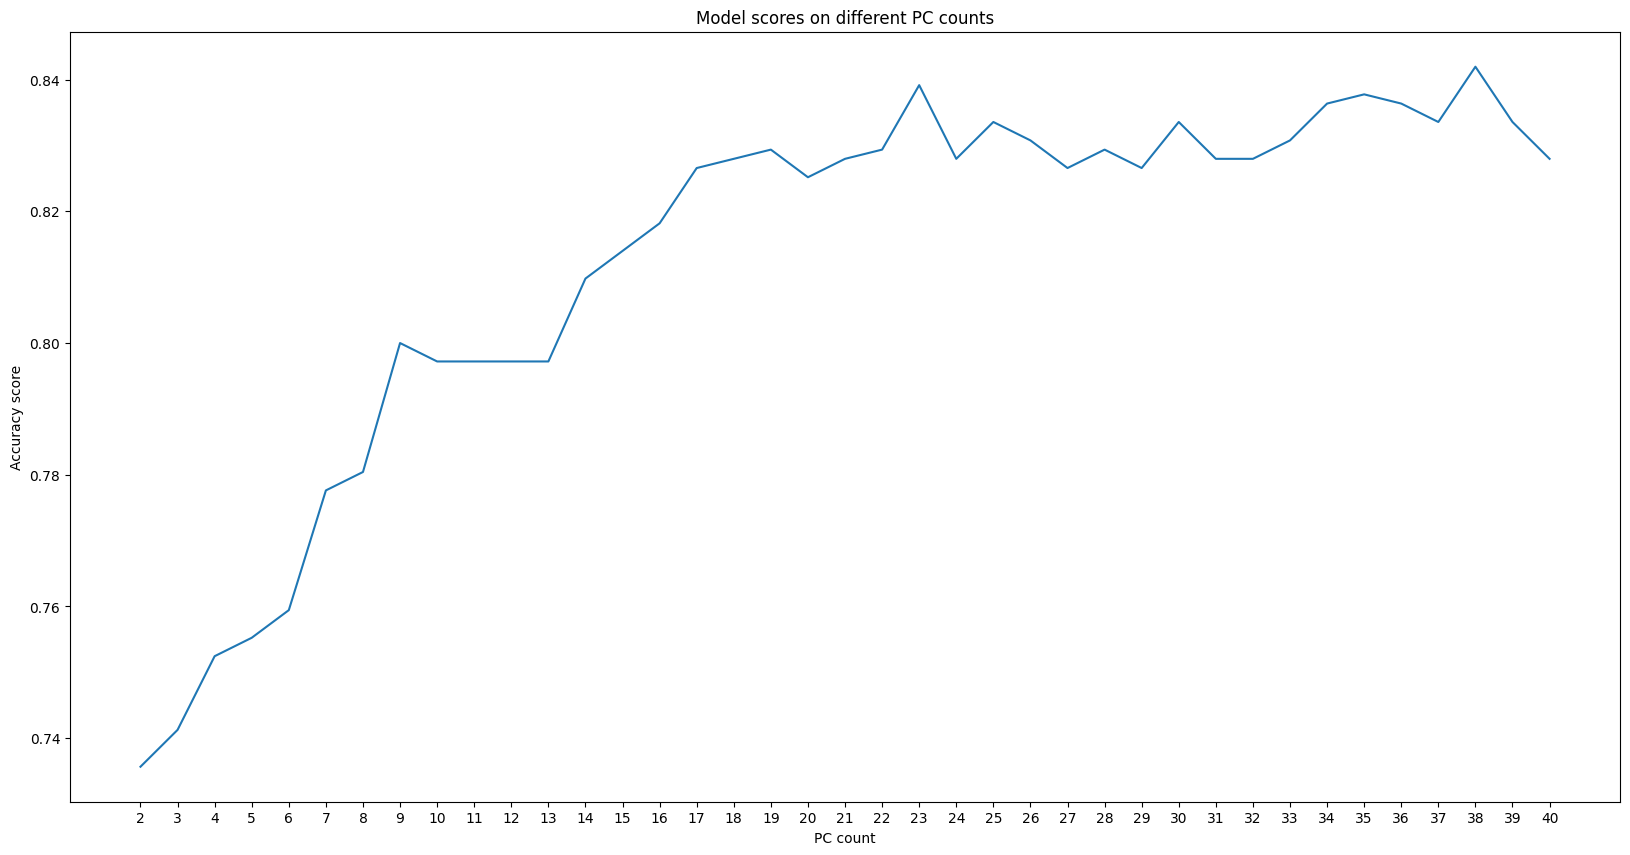

In [26]:
def bayes(epochs):
  return GaussianNB()
model = train_and_predict(bayes, x_tr, y_tr, 40, 100)

In [28]:
nv = 23
x_tr_c = x_tr.iloc[:, :nv]
x_test_c = x_test.iloc[:, :nv]
model = bayes(100)
model.fit(x_tr_c, y_tr)
y_pred = model.predict(x_test_c)
print(classification_report(y_test, y_pred))
export(model, nv, all_data, "bayes")

              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.29      0.67      0.40         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.40      0.50      0.44         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.50      0.40      0.44         5
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00         4
          12       0.45      1.00      0.62         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       1.00      0.40      0.57        10
          16       1.00      1.00      1.00         7
          17       0.83    

Наивная модель Байеса.\
Модель, основанная на теореме Байеса\
$$P(y_k|X) = \frac{P(y_k)P(X|y_k)}{P(X)}$$
Где $P(y_k|X) - апостериорная\ вероятность\ принадлежности\ объекта\ к\ классу\ X\ с\ учётом\ его\ признаков\ y_k$
$P(y_k) -\ априорная\ вероятность\ такого\ набора\ признаков$
$P(X|y_k) -\ правдоподобие, то\ есть\ вероятность\ наличия\ признаков\ при\ заданном\ классе.$
$P(x) - априорная\ вероятность\ принадлежности\ к\ классу\ X.$
Здесь признаки считаются независимыми, что позволяет нам предположить, что
$P(y_k) = Π_{i=1}^ky_i$ \
Поскольку изначально говорится о дискретных признаках, а в нашем случае признаки непрерывны используется Гауссианский классификатор, предполагающий, что признаки имеют стандартное распределение по закону Гаусса
$$P(X|y_i) = \frac{1}{\sqrt{2\pi\sigma_y^2}}exp(-\frac{(y_i - \mu_i)^2}{2\sigma_i})$$
Где $\sigma_i, \mu_i$ - стандартное и среднее отклонения признаков в классе X.\
Для нескольких классов используется схожий с описанным ранее подход. \
К достоинствам содели также можно отнести лёгкую обучаемость: всё сводится к вычислению статистических закономерностей и не требует итеративного обучения. \
Данная модель при всей своей простоте показала на удивление хорошие результаты, сравнимые с рассматриваемыми ниже ансамблевыми моделями. Судя по всему, распределение главных компонент близко к нормальному.

In [29]:
def dec_tree(epochs):
  return DecisionTreeClassifier(max_depth = 1000, min_samples_split = 19)

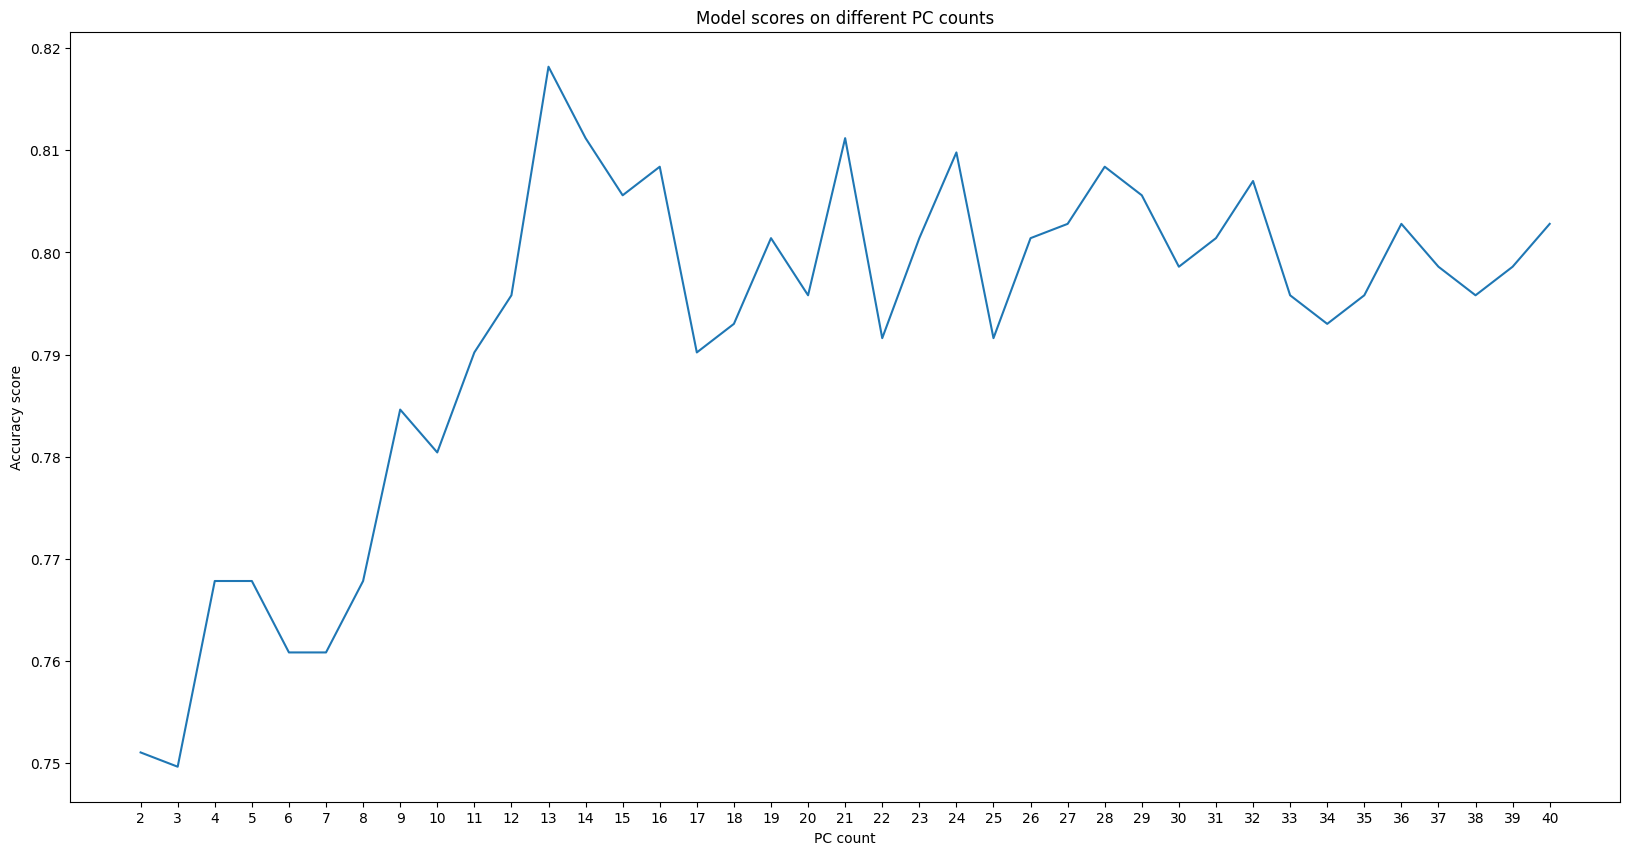

In [30]:
model = train_and_predict(dec_tree, x_tr, y_tr, 40, 1000)

In [31]:
nv = 15
x_tr_c = x_tr.iloc[:, :nv]
x_test_c = x_test.iloc[:, :nv]
model = dec_tree(1000)
model.fit(x_tr_c, y_tr)
y_pred = model.predict(x_test_c)
print(classification_report(y_test, y_pred))
populations[2]
export(model, nv, all_data, "tree")

              precision    recall  f1-score   support

           0       0.50      0.83      0.62         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.20      0.33      0.25         3
           4       1.00      1.00      1.00         5
           5       0.88      1.00      0.93         7
           6       0.50      0.50      0.50         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.60      0.60      0.60         5
          10       1.00      1.00      1.00         5
          11       0.80      1.00      0.89         4
          12       0.67      0.80      0.73         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.78      0.70      0.74        10
          16       1.00      0.86      0.92         7
          17       0.80    

# Дерево решений

Алгоритм строит дерево решений, разделяя на каждой итерации набор данных на два меньших так, чтобы индекс Джини, достоверность или энтропия были наименьшим, наибольшей или наибольшей соответственно. Гиперпараметры определяют минимальное изменение функции потерь для разделения, минимальное число объектов в делимом наборе, максимальную глубину дерева.
## Алгоритм поиска порогового значения для деления данных

+ Сортируем объекты по возрастанию признака
+ Перебираем пороговые значения, на которых меняется класс
+ Ищем оптимальное опроговое значение

In [33]:
def forest(epochs):
  return RandomForestClassifier(n_estimators=epochs)

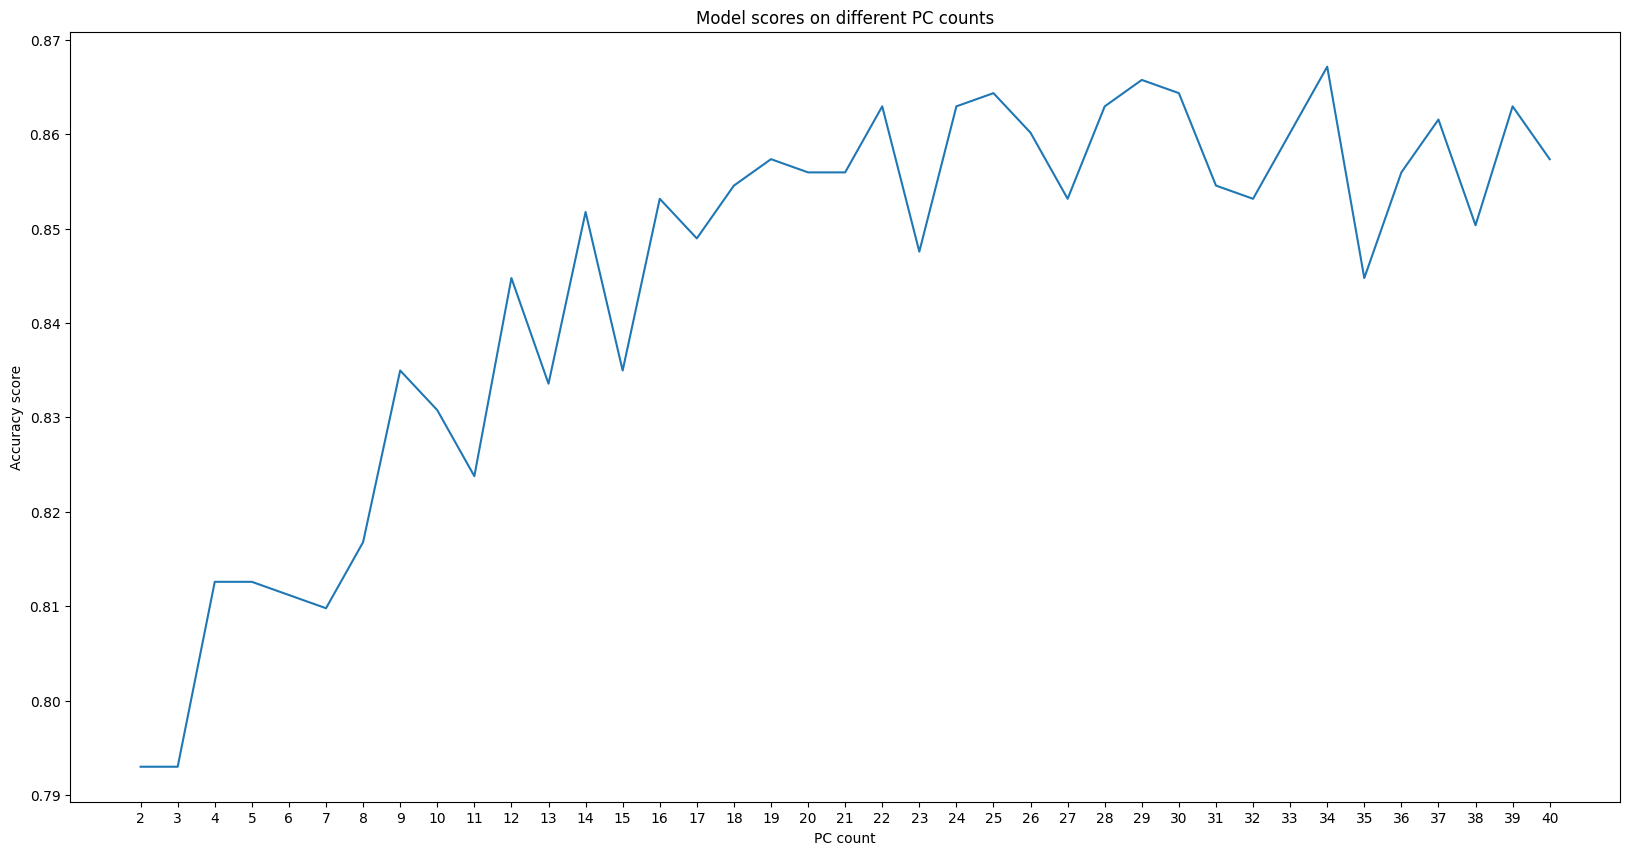

In [35]:
model = train_and_predict(forest, x_tr, y_tr, 40, 100)

In [38]:
nv = 34
x_tr_c = x_tr.iloc[:, :nv]
x_test_c = x_test.iloc[:, :nv]
model = forest(100)
model.fit(x_tr_c, y_tr)
y_pred = model.predict(x_test_c)
print(classification_report(y_test, y_pred))
export(model, nv, all_data, "rf")

              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.25      0.67      0.36         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.67      0.50      0.57         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.67      0.80      0.73         5
          10       1.00      1.00      1.00         5
          11       1.00      1.00      1.00         4
          12       0.42      1.00      0.59         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.67      0.20      0.31        10
          16       1.00      1.00      1.00         7
          17       0.92    

## Случайный лес
Первый рассматриваемый здесь ансамблевый метод предполагает использование большого количества деревьев решений, обучаемых а случайных фрагментах датасета и в дальнейшем используемым в ансамбле: каждое дерево выдаёт свой прогноз относительно точки, а в качестве итогового прогноза выбирается argmax от прогнозов леса.

In [39]:
def xgboost(epochs):
  return XGBClassifier(n_estimators=epochs)

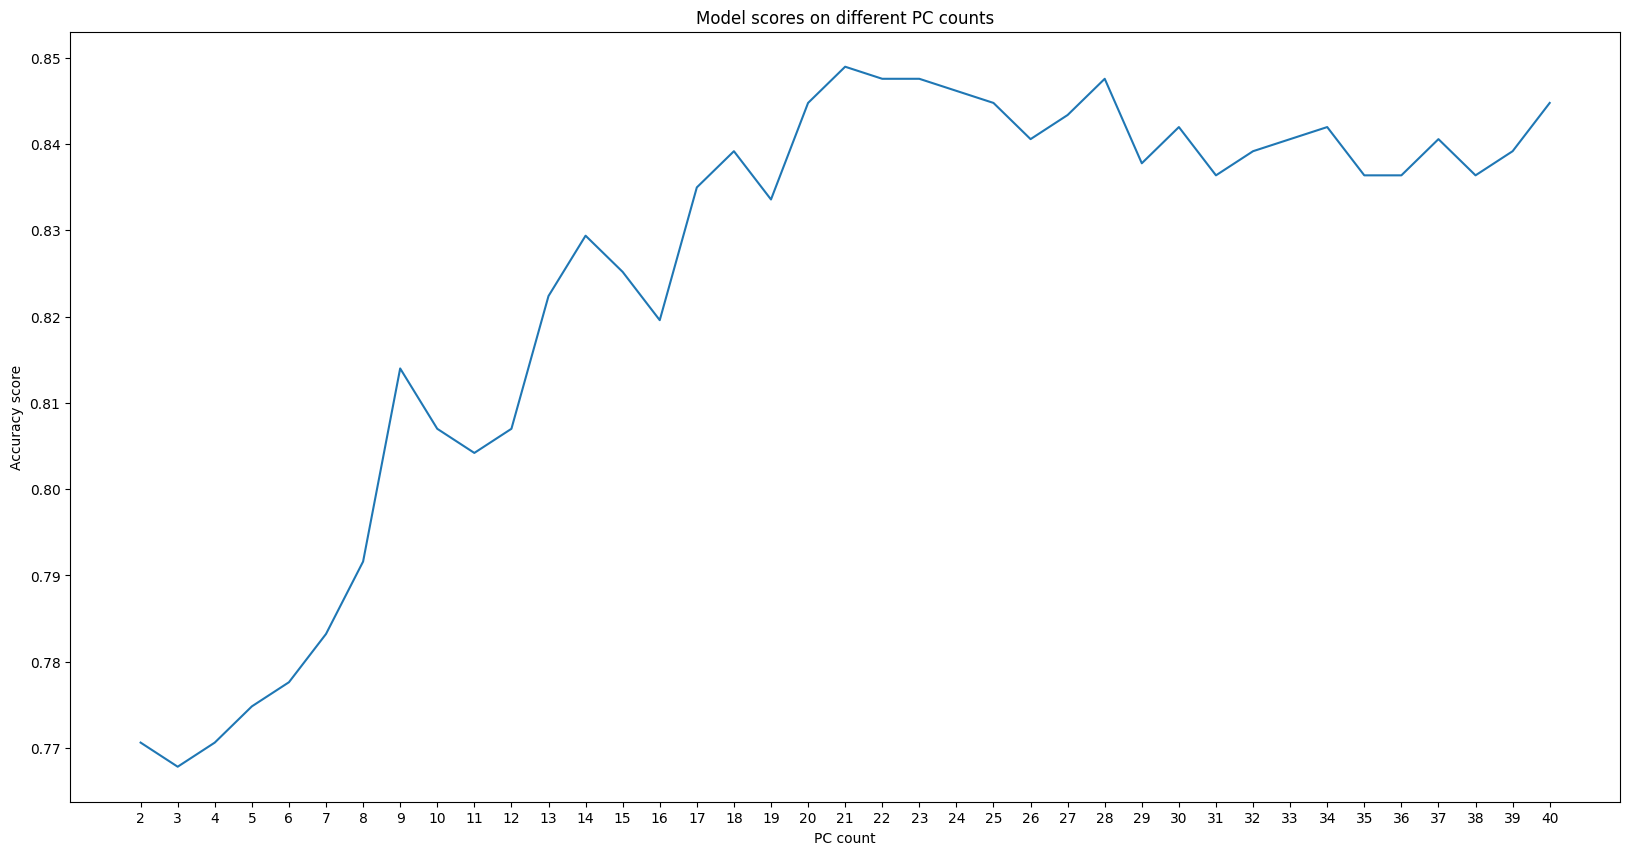

In [40]:
model = train_and_predict(xgboost, x_tr, y_tr, 40, 100)

In [43]:
nv = 21
x_tr_c = x_tr.iloc[:, :nv].values
x_test_c = x_test.iloc[:, :nv].values
model = xgboost(100)
model.fit(x_tr_c, y_tr)
y_pred = model.predict(x_test_c)
print(classification_report(y_test, y_pred))
# XGBoost нет в skl2onnx, делаем по-другому
onnx_model = convert_xgboost(model, initial_types=[('input', FloatTensorType([None, nv]))])

# Save the ONNX model
with open("xgboost_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.25      0.33      0.29         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.25      0.25      0.25         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.40      0.40      0.40         5
          10       1.00      1.00      1.00         5
          11       0.57      1.00      0.73         4
          12       0.44      0.80      0.57         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.67      0.40      0.50        10
          16       1.00      0.86      0.92         7
          17       0.91    

XGBoost

In [44]:
def ada(epochs):
  return AdaBoostClassifier(n_estimators=epochs)

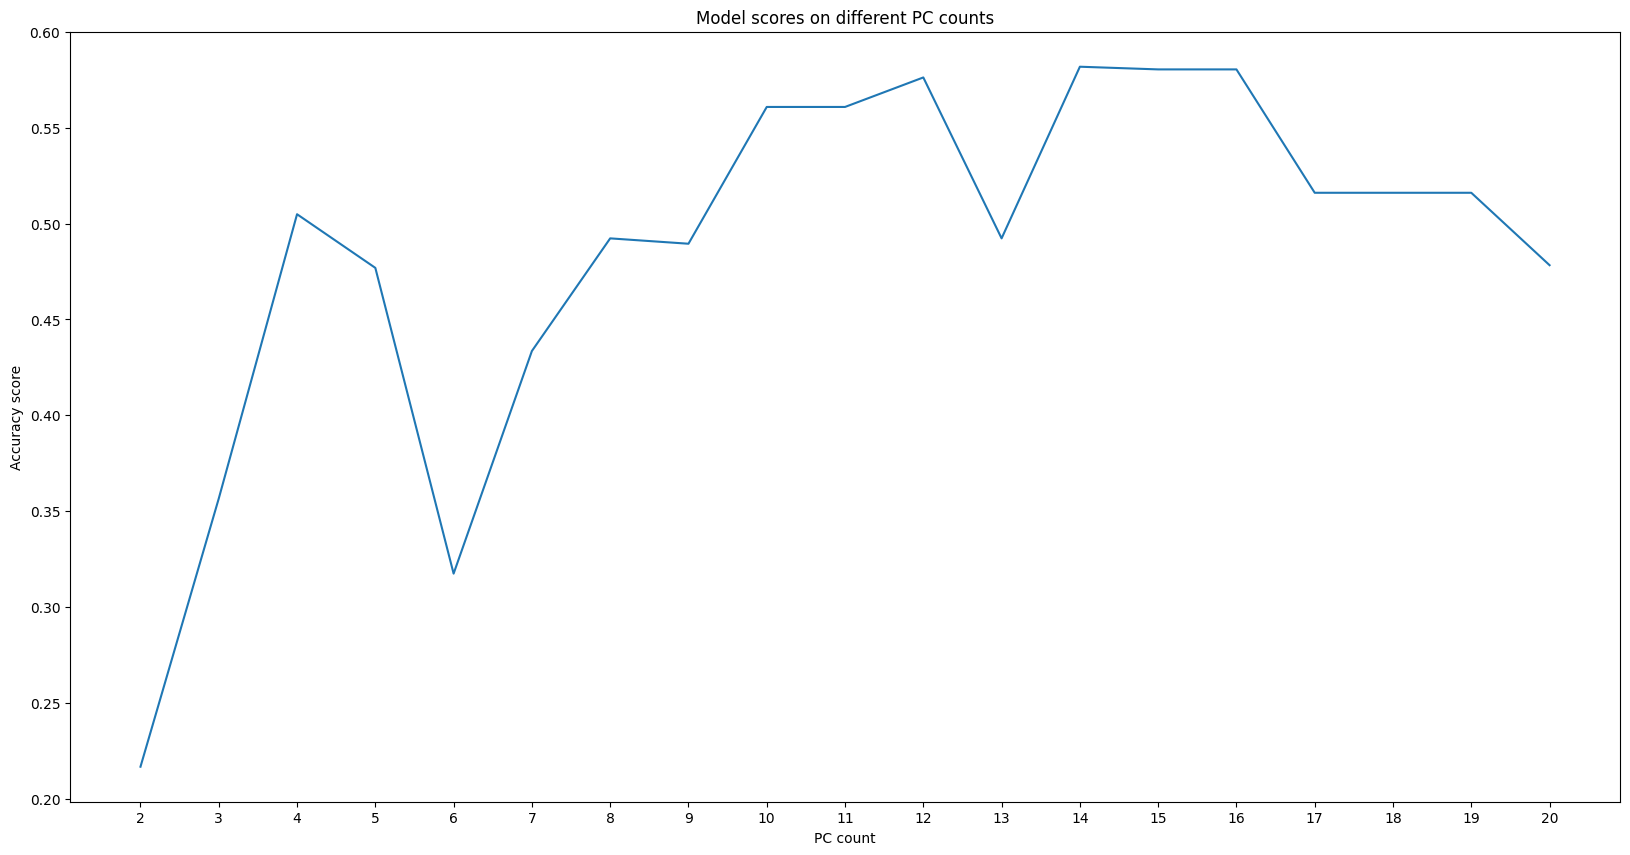

In [45]:
model = train_and_predict(ada, x_tr, y_tr, 20, 1000)

In [46]:
nv = 16
x_tr_c = x_tr.iloc[:, :nv]
x_test_c = x_test.iloc[:, :nv]
model = ada(1000)
model.fit(x_tr_c, y_tr)
y_pred = model.predict(x_test_c)
print(classification_report(y_test, y_pred))
export(model, nv, all_data, "ada")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.33      1.00      0.50         6
           1       0.44      0.67      0.53         6
           2       1.00      1.00      1.00         8
           3       0.00      0.00      0.00         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.33      1.00      0.50         4
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         2
           9       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         5
          11       1.00      1.00      1.00         4
          12       0.00      0.00      0.00         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.00      0.00      0.00        10
          16       1.00      0.71      0.83         7
          17       0.00    

Adaboost

In [47]:
def grad(epochs):
  return GradientBoostingClassifier(n_estimators=epochs)


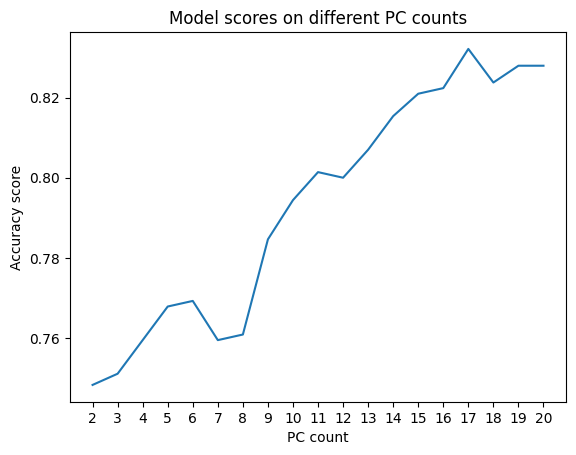

In [ ]:
model = train_and_predict(grad, x_tr, y_tr, 20, 100)

In [48]:
nv = 17
x_tr_c = x_tr.iloc[:, :nv]
x_test_c = x_test.iloc[:, :nv]
model = grad(1000)
model.fit(x_tr_c, y_tr)
y_pred = model.predict(x_test_c)
print(classification_report(y_test, y_pred))
export(model, nv, all_data, "grad")

              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         8
           3       0.25      0.33      0.29         3
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         7
           6       0.29      0.50      0.36         4
           7       1.00      1.00      1.00         4
           8       0.67      1.00      0.80         2
           9       0.33      0.20      0.25         5
          10       1.00      1.00      1.00         5
          11       0.67      1.00      0.80         4
          12       0.56      1.00      0.71         5
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.83      0.50      0.62        10
          16       1.00      0.86      0.92         7
          17       0.83    

Gradient Boosting

25